# Japan Demographics Analysis - Population Change 1995-2020

This notebook analyzes Japanese prefectural and municipal population data to answer:
1. Percentage population changes by prefecture (1995-2020)
2. Time series of percentage changes relative to 1995
3. Relationship between 1995 population size and percentage change for prefectures
4. Relationship between city size and percentage change for cities
5. Relationship between population density and percentage growth for prefectures

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
subdivs = pd.read_excel('/home/suwaraich/Data_Science_Research/Week3/japan-subdivisions.xlsx')
areas = pd.read_excel('/home/suwaraich/Data_Science_Research/Week3/japan-prefecture-areas.xlsx')

# Extract prefectures
pref = subdivs[subdivs['Status'] == 'Prefecture'].reset_index(drop=True)
pref_names = pref['Name'].tolist()

# Extract cities
cities_df = subdivs[subdivs['Status'] == 'City (-shi)'].reset_index(drop=True)

# Extract density from areas file
dens_col = [c for c in areas.columns if 'density' in str(c).lower()][0]
dens = areas[areas['Prefecture'].isin(pref_names)].reset_index(drop=True)[['Prefecture', dens_col]].dropna()

# Set plot style
sns.set_style('whitegrid')
sns.set_palette('Set2')

print(f'Loaded {len(pref)} prefectures, {len(cities_df)} cities, {len(dens)} prefectures with density data')
print(f'\\nColumns in subdivs: {subdivs.columns.tolist()}')
print(f'Density column name: {dens_col}')


Loaded 46 prefectures, 792 cities, 39 prefectures with density data
\nColumns in subdivs: ['Name', 'Status', 'Native', 'pop1995', 'pop2000', 'pop2005', 'pop2010', 'pop2015', 'pop2020', 'Unnamed: 9']
Density column name: Density
(/km2)


## Part A: Percentage change in population for prefectures (1995-2020)

This calculates the percentage change from 1995 to 2020 for each prefecture.

In [5]:
# Calculate percentage change
pref['pct_change'] = (pref['pop2020'] - pref['pop1995']) / pref['pop1995'] * 100

# Display all prefectures sorted by percentage change
results = pref[['Name', 'pop1995', 'pop2020', 'pct_change']].sort_values('pct_change')
print('County (Prefecture)\t1995 Pop\t2020 Pop\t% Change')
print('='*70)
for idx, row in results.iterrows():
    print(f'{row["Name"]:25s} \t{row["pop1995"]:>10,.0f} \t{row["pop2020"]:>10,.0f} \t{row["pct_change"]:>+8.2f}%')

print(f'\\nSummary statistics:')
print(f'  Overall average change: {pref["pct_change"].mean():.2f}%')
print(f'  Median change: {pref["pct_change"].median():.2f}%')
print(f'  Growth: {(pref["pct_change"] > 0).sum()} prefectures')
print(f'  Decline: {(pref["pct_change"] < 0).sum()} prefectures')


County (Prefecture)	1995 Pop	2020 Pop	% Change
Akita                     	 1,213,667 	   959,502 	  -20.94%
Aomori                    	 1,481,663 	 1,237,984 	  -16.45%
Kōchi                     	   816,704 	   691,527 	  -15.33%
Nagasaki                  	 1,544,934 	 1,312,317 	  -15.06%
Yamagata                  	 1,256,958 	 1,068,027 	  -15.03%
Iwate                     	 1,419,505 	 1,210,534 	  -14.72%
Wakayama                  	 1,080,435 	   922,584 	  -14.61%
Fukushima                 	 2,133,592 	 1,833,152 	  -14.08%
Yamaguchi                 	 1,555,543 	 1,342,059 	  -13.72%
Tokushima                 	   832,427 	   719,559 	  -13.56%
Shimane                   	   771,441 	   671,126 	  -13.00%
Niigata                   	 2,488,364 	 2,201,272 	  -11.54%
Kagoshima                 	 1,794,224 	 1,588,256 	  -11.48%
Ehime                     	 1,506,700 	 1,334,841 	  -11.41%
Tottori                   	   614,929 	   553,407 	  -10.00%
Miyazaki                  	 1,175,819 

## Part B: Time series of percentage change relative to 1995

Line plot showing percentage change for each census year (2000, 2005, ..., 2020) relative to 1995 baseline.

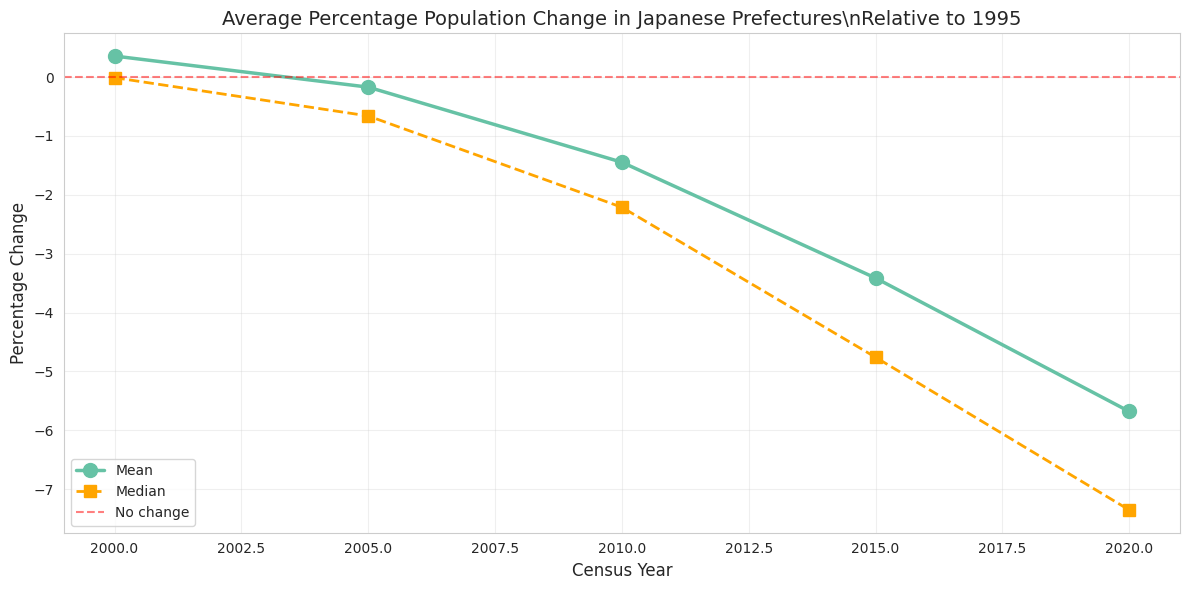

Mean change by year:
  2000: 0.36%
  2005: -0.17%
  2010: -1.45%
  2015: -3.41%
  2020: -5.68%


In [7]:
# Calculate average percentage change for each year relative to 1995
years = [2000, 2005, 2010, 2015, 2020]
pop_cols = ['pop2000', 'pop2005', 'pop2010', 'pop2015', 'pop2020']

pct_changes_by_year = []
for yr, col in zip(years, pop_cols):
    change = (pref[col] - pref['pop1995']) / pref['pop1995'] * 100
    pct_changes_by_year.append(change.mean())

# Also calculate median
median_changes = []
for yr, col in zip(years, pop_cols):
    change = (pref[col] - pref['pop1995']) / pref['pop1995'] * 100
    median_changes.append(change.median())

# Plot
plt.figure(figsize=(12, 6))
plt.plot(years, pct_changes_by_year, 'o-', linewidth=2.5, markersize=10, label='Mean')
plt.plot(years, median_changes, 's--', linewidth=2, markersize=8, label='Median', color='orange')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No change')
plt.title('Average Percentage Population Change in Japanese Prefectures\\nRelative to 1995', fontsize=14)
plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Percentage Change', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('/home/suwaraich/ds_work/population_project/mean_change_ts.png', dpi=150)
plt.show()

print('Mean change by year:')
for yr, val in zip(years, pct_changes_by_year):
    print(f'  {yr}: {val:.2f}%')


## Part C: Scatter plot of 1995 population vs percentage change for prefectures

Examine whether larger prefectures tend to grow or decline more relative to their size.

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pref['pop1995'], y=pref['pct_change'], s=100, alpha=0.7)
plt.title('1995 Population vs Percentage Change (1995-2020)\\nfor Japanese Prefectures', fontsize=13)
plt.xlabel('Population in 1995', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Pearson correlation
corr, p_val = stats.pearsonr(pref['pop1995'], pref['pct_change'])
print(f'Pearson correlation coefficient: r = {corr:.4f}')
print(f'P-value: {p_val:.6f}')
plt.text(0.05, 0.95, f'r = {corr:.4f}\\np = {p_val:.6f}', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('/home/suwaraich/ds_work/population_project/scatter_prefectures.png', dpi=150)
plt.show()

if corr < 0:
    print('\\nInterpretation: There is a negative correlation between 1995 population and growth.')
    print('Larger prefectures tend to have smaller percentage growth (or larger decline).')
else:
    print('\\nInterpretation: There is a positive correlation between 1995 population and growth.')
    print('Larger prefectures tend to grow more relative to their size.')


## Part D: Relationship between city size and percentage change for cities

Examine whether larger cities tend to grow more or less than smaller ones.

In [ ]:
# Calculate percentage change for cities
cities_df['pct_change'] = (cities_df['pop2020'] - cities_df['pop1995']) / cities_df['pop1995'] * 100

# Sort by size
cities_sorted = cities_df.sort_values('pop1995', ascending=False).reset_index(drop=True)

print('Top 10 largest cities (by 1995 population):')
print(cities_sorted[['Name', 'pop1995', 'pop2020', 'pct_change']].head(10).to_string(index=False))
print('\\nBottom 10 largest cities (by 1995 population):')
print(cities_sorted[['Name', 'pop1995', 'pop2020', 'pct_change']].tail(10).to_string(index=False))


In [ ]:
# Scatter plot for cities
plt.figure(figsize=(12, 6))
sns.scatterplot(x=cities_sorted['pop1995'], y=cities_sorted['pct_change'], s=60, alpha=0.6)
plt.title('City Size (1995) vs Percentage Population Change (1995-2020)', fontsize=13)
plt.xlabel('City Population in 1995', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Pearson correlation
corr_city, p_val_city = stats.pearsonr(cities_sorted['pop1995'], cities_sorted['pct_change'])
print(f'\\nPearson correlation coefficient: r = {corr_city:.4f}')
print(f'P-value: {p_val_city:.6f}')
plt.text(0.05, 0.95, f'r = {corr_city:.4f}\\np = {p_val_city:.6f}',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('/home/suwaraich/ds_work/population_project/scatter_cities.png', dpi=150)
plt.show()

if corr_city < 0:
    print('\\nInterpretation: Larger cities tend to have smaller percentage growth.')
else:
    print('\\nInterpretation: Larger cities tend to have larger percentage growth.')


## Part E: Relationship between population density and percentage growth for prefectures

Use the prefecture density data to examine whether more densely populated prefectures grow more or less.

In [ ]:
# Merge density data with prefecture data
dens_merged = pref.merge(dens, left_on='Name', right_on='Prefecture', how='inner')
dens_merged['pct_change'] = (dens_merged['pop2020'] - dens_merged['pop1995']) / dens_merged['pop1995'] * 100

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=dens_merged[dens_col], y=dens_merged['pct_change'], s=100, alpha=0.7)
plt.title('Prefecture Population Density vs Percentage Growth (1995-2020)', fontsize=13)
plt.xlabel(f'Population Density ({dens_col})', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Pearson correlation
corr_dens, p_val_dens = stats.pearsonr(dens_merged[dens_col], dens_merged['pct_change'])
print(f'\\nPearson correlation coefficient: r = {corr_dens:.4f}')
print(f'P-value: {p_val_dens:.6f}')
plt.text(0.05, 0.95, f'r = {corr_dens:.4f}\\np = {p_val_dens:.6f}',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('/home/suwaraich/ds_work/population_project/scatter_density.png', dpi=150)
plt.show()

if corr_dens < 0:
    print('\\nInterpretation: Denser prefectures tend to have smaller percentage growth.')
    print('Population may be decreasing in urban areas or increasing in less dense areas.')
else:
    print('\\nInterpretation: Denser prefectures tend to have larger percentage growth.')
    print('Population is concentrating in more densely populated areas.')


## Summary

1. **County (Prefecture) changes** - Displayed in Part A table with all prefectures sorted by growth/decline
2. **Time series** - Shows trend of average percentage change for prefectures from 1995-2020
3. **Population size correlation (prefectures)** - Pearson correlation tests relationship between 1995 population and growth
4. **City size correlation** - Pearson correlation tests relationship between city size and growth
5. **Density correlation** - Pearson correlation tests relationship between density and growth

Expected pattern: Rural flight in Japan, with populations concentrating in urban areas.
